## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
import msml610_utils as ut
import L05_02_01_bias_variance_utils as utils

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux 589569fe8102 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


# Cell 1: Approximation

**Goal**:
- Demonstrate the concept of approximation - how well different models can fit a target function
- Visualize how a constant model (horizontal line) and a linear model (diagonal line) approximate a sinusoidal target function $f(x) = \sin(\pi x)$ for $x \in [-1, 1]$
- Compare approximation capability between simple (constant) and more complex (linear) models

**Plots**:
- Display three plots:
  - _True function vs constant model_: Shows $g_0(x) = b$ (mean of $f(x)$), with orange shading for approximation error
  - _True function vs linear model_: Shows $g_1(x) = ax + b$ (fitted using least squares), with orange shading for approximation error
  - _Comments_: Displays approximation errors and observations

**Parameters**:
- None (this is a static visualization)

**Key observations**:
- The constant model has high approximation error - it cannot capture any variation in the target function
- The linear model has lower approximation error - it can capture the general trend, though not the curvature
- Lower approximation error means better fit, but doesn't always mean better learning (as we'll see with bias-variance tradeoff)

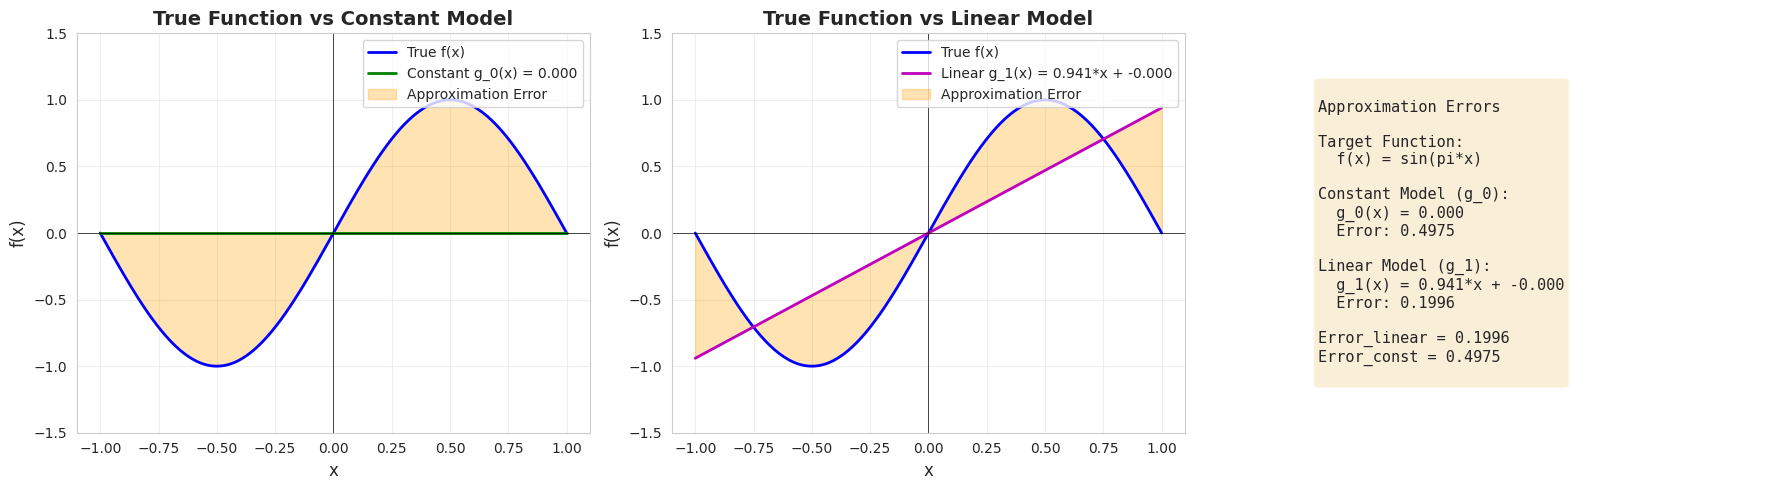

In [3]:
# Display approximation comparison between constant and linear models.
utils.cell1_approximation()

# Cell 2: Learning Once

**Goal**:
- Demonstrate the difference between learning and approximation
- Show how models trained on a limited training set (learning) perform differently than models that approximate the full function
- Illustrate the key difference between in-sample error ($E_{in}$) and out-of-sample error ($E_{out}$)

**Plots**:
- Display three plots:
  - _Constant model $g_0$_: Shows true function $f(x) = \sin(\pi x)$, fitted model, and training points (red dots), with $E_{in}$ and $E_{out}$ displayed
  - _Linear model $g_1$_: Shows true function, fitted model, and training points, with $E_{in}$ and $E_{out}$ displayed
  - _Comments_: Displays errors and observations about learning vs approximation

**Parameters**:
- `seed`: Random seed controlling which training points are sampled
- `N_samples`: Number of random points in the training set (default: 2)

**Key observations**:
- $E_{in}$ measures how well the model fits the training data
- $E_{out}$ measures how well the model generalizes to the full function
- With very few samples (e.g., $N=2$), a linear model can achieve $E_{in}=0$ (perfect fit on training data) but still have high $E_{out}$
- This demonstrates that learning from limited data is fundamentally different from approximation
- Try different seeds to see how training set selection affects performance

In [4]:
# Display learning from N random samples with interactive controls.
utils.cell2_learning_once()

Output()

# Cell 3: Learning (Bias-Variance Decomposition)

**Goal**:
- Visualize the bias-variance tradeoff by showing how models trained on different random training sets vary around the true function $f(x) = \sin(\pi x)$
- Demonstrate bias and variance decomposition by running multiple learning experiments with different training sets
- Show how model complexity affects both bias (systematic error) and variance (sensitivity to training data)

**Plots**:
- Display three plots:
  - _Constant models_: True function and all fitted constant models (green lines with transparency), with dashed line showing average model
  - _Linear models_: True function and all fitted linear models (magenta lines with transparency), with dashed line showing average model
  - _Comments_: Average errors and explanation of bias-variance tradeoff

**Parameters**:
- `seed`: Random seed for reproducibility
- `N_samples`: Number of training points per experiment (default: 2)
- `N_experiments`: Number of different training sets to generate (default: 100)

**Key observations**:
- Constant model ($g_0$): Low variance (all lines very similar), high bias (far from true function) - the model is too simple to capture the pattern
- Linear model ($g_1$): Higher variance (lines spread out more), lower bias (average model closer to true function) - the model is more flexible but sensitive to training data
- This illustrates the bias-variance tradeoff: simpler models have low variance but high bias; more complex models have lower bias but higher variance
- The total out-of-sample error decomposes as: $E_{out} = \text{bias}^2 + \text{variance} + \text{noise}$
- Try increasing `N_samples` to see how more data reduces variance
- Try increasing `N_experiments` to get more stable estimates of bias and variance

In [5]:
# Display bias-variance decomposition over multiple experiments.
utils.cell3_learning_bias_variance()

Output()

## Cell 4: Learning Plots (Bias-Variance as Function of Training Set Size)

**Goal**:
- Show how bias, variance, and overall error change as we increase the number of training samples
- Visualize the bias-variance decomposition as a function of training set size ($N_{samples}$)
- Demonstrate the classic bias-variance curves and how more data affects both components of the learning error

**Plots**:
- Display three plots:
  - _Constant model ($g_0$)_: Shows $E_{in}$, $E_{out}$, $\text{Bias}^2$, and $\text{Variance}$ as functions of $N_{samples}$
  - _Linear model ($g_1$)_: Shows $E_{in}$, $E_{out}$, $\text{Bias}^2$, and $\text{Variance}$ as functions of $N_{samples}$
  - _Comments_: Error decomposition formula and observations
- Show error decomposition: For a deterministic target function (no noise), $E_{out} = \text{Bias}^2 + \text{Variance}$

**Parameters**:
- `seed`: Random seed for reproducibility (fixed to ensure consistent comparison)
- `N_experiments`: Number of experiments to average over for each $N_{samples}$ value
- `max_N_samples`: Maximum number of training samples to test

**Key observations**:
- **Constant model**: Very low variance (almost constant across $N_{samples}$) because it's insensitive to training data, but high bias because it cannot capture the sinusoidal pattern
- **Linear model**: Higher variance (especially with few samples) because it's more flexible and sensitive to training data, but lower bias because it can better approximate the target function
- **As $N_{samples}$ increases**: Variance decreases for both models (more data leads to more stable fits), while bias remains relatively constant (determined by model capacity)
- **$E_{out}$ decomposition**: You can verify that $E_{out} \approx \text{Bias}^2 + \text{Variance}$ by comparing the curves
- **The bias-variance tradeoff**: Simpler models (constant) have low variance but high bias; more complex models (linear) have higher variance but lower bias
- Try increasing `N_experiments` to get smoother, more stable curves

In [6]:
# Display bias-variance decomposition as a function of N_samples.
utils.cell4_learning_plots()

Output()

## Cell 5: Learning with Noise (Bias-Variance Decomposition)

**Goal**:
- Extend Cell 3 by adding Gaussian noise to the training data
- Demonstrate how noise affects the bias-variance tradeoff
- Show how adding noise to training labels $y = f(x) + \mathcal{N}(0, \sigma^2)$ affects both the variance and out-of-sample error of learned models

**Plots**:
- Display three plots:
  - _Constant models_: True function and all fitted constant models (green lines with transparency), with dashed line showing average model
  - _Linear models_: True function and all fitted linear models (magenta lines with transparency), with dashed line showing average model
  - _Comments_: Average errors and explanation of noise effects

**Parameters**:
- `seed`: Random seed for reproducibility
- `N_samples`: Number of training points per experiment (default: 2)
- `N_experiments`: Number of different training sets to generate (default: 100)
- `noise_std`: Standard deviation of Gaussian noise added to training labels (default: 0.0)

**Key observations**:
- **With $\sigma = 0$**: Same behavior as Cell 3 (no noise case)
- **With $\sigma > 0$**: Training data is corrupted by Gaussian noise
  - Models try to fit the noisy observations instead of the true function
  - This increases variance for both models (more sensitivity to data)
  - $E_{out}$ increases because models partially fit the noise
  - The error decomposition becomes: $E_{out} = \text{Bias}^2 + \text{Variance} + \sigma^2$ (noise variance)
- **Constant model**: Still has low variance, but noise increases $E_{out}$
- **Linear model**: Variance increases significantly with noise (tries to fit noise)
- Try increasing `noise_std` to see how noise affects the spread of fitted models
- Try increasing `N_samples` to see how more data helps average out the noise

In [7]:
# Display bias-variance decomposition with noise over multiple experiments.
utils.cell5_learning_with_noise()

Output()

## Cell 6: Learning Plots with Noise (Bias-Variance as Function of Training Set Size)

**Goal**:
- Extend Cell 4 by adding Gaussian noise to the training data
- Visualize how $E_{in}$, $E_{out}$, $\text{Bias}^2$, and $\text{Variance}$ change as a function of training set size when training data is corrupted by Gaussian noise
- Demonstrate how more data helps mitigate the effects of noise

**Plots**:
- Display three plots:
  - _Constant model ($g_0$)_: Shows error components as functions of $N_{samples}$
  - _Linear model ($g_1$)_: Shows error components as functions of $N_{samples}$
  - _Comments_: Error decomposition with noise formula and observations
- Show error decomposition with noise: $E_{out} = \text{Bias}^2 + \text{Variance} + \sigma^2$ (noise variance $\sigma^2$ is irreducible error)

**Parameters**:
- `seed`: Random seed for reproducibility (fixed to ensure consistent comparison)
- `N_experiments`: Number of experiments to average over for each $N_{samples}$ value
- `max_N_samples`: Maximum number of training samples to test
- `noise_std`: Standard deviation of Gaussian noise $\sigma$ added to training labels (default: 0.0)

**Key observations**:
- **With $\sigma = 0$**: Same behavior as Cell 4 (deterministic case)
- **With $\sigma > 0$**: Training data includes random noise
  - Variance increases for both models compared to the no-noise case
  - $E_{out}$ increases by approximately $\sigma^2$ (the irreducible error from noise)
  - As $N_{samples}$ increases, variance decreases (more data averages out noise)
  - Bias remains relatively constant (determined by model capacity, not noise)
- **The noise term**: Represents the best possible error - even a perfect model cannot do better than $\sigma^2$ when learning from noisy data
- **More data helps**: Increasing $N_{samples}$ reduces the variance component but cannot reduce the noise component
- Try setting `noise_std = 0.1` or `0.2` to see the noise effect
- Try increasing `max_N_samples` to see how variance continues to decrease with more data
- Compare with Cell 4 ($\sigma = 0$) to see the additional error from noise

In [8]:
# Display bias-variance decomposition with noise as a function of N_samples.
utils.cell6_learning_plots_with_noise()

Output()